# Probabilistic Language Models and Collocations

## Data Understanding

A few text on which to work on:

In [92]:
books_urls = [
    ("Rowling", "Harry Potter and the Sorcerer's Stone", "https://dgoldberg.sdsu.edu/515/harrypotter.txt"),
    ("Melville", "Moby Dick - ch1", "https://dgoldberg.sdsu.edu/515/mobydick.txt"),
    ("Lucas", "STAR WARS - Episode IV", "https://dgoldberg.sdsu.edu/515/starwarsiv.txt"),
    ("Shakespeare", "Act III", 'https://dgoldberg.sdsu.edu/515/shakespeare.txt'),
    ]


Let's download them and save them to a file in a new directory

In [93]:
from urllib import request
import os # for interacting with the operating system; it allows us to create folders, list files, and build file paths

In [94]:
new_directory = 'resources/'
os.makedirs(new_directory, exist_ok=True)  # does not raise an error if the folder already exists

def download(url):
    response = request.urlopen(url)
    text = response.read().decode('utf-8', errors='ignore')
    return text

def save(text, filename):
    with open(filename, mode='w', encoding='utf-8', errors='ignore') as outputfile:
        outputfile.write(text)  # ignores invalid characters


# iterate through the list of books (each entry has author, title, and url)
for author, title, url in books_urls:
    try:
        text = download(url)
        # save the downloaded text into a file named "author - title"
        filename = f"{author}.txt"
        save(text, os.path.join(new_directory, filename))
        print(f"saved {author}, {title}")
    except Exception as e:
        # if an error occurs, print an error message but continue with the next book
        print(f"error {author}, {title} -> {e}")
        continue



saved Rowling, Harry Potter and the Sorcerer's Stone
saved Melville, Moby Dick - ch1
saved Lucas, STAR WARS - Episode IV
saved Shakespeare, Act III


`os.listdir(new_directory)` shows all the files and folders inside the directory `new_directory`.

In [95]:
os.listdir(new_directory)

['Lucas.txt', 'Melville.txt', 'Rowling.txt', 'Shakespeare.txt']

### Reading the text file

We experiment with two different methods for reading the contents of a text file.

Although both methods access the same file, they return *different types of objects* and therefore yield *different lengths* when using `len()`.

- `read()` loads the **entire file as a single string**  
- `readlines()` loads the **file as a list of strings**, one per line.


The `read()` method loads the **entire content of the file as a single string**.

This means that all characters, including spaces, tabs, and newline characters (`\n`) are part of one continuous text sequence.

When using `len()` on the result, it returns the **total number of characters** in the file.


In [96]:
filename = 'Shakespeare.txt'
path_to_file = os.path.join(new_directory, filename)

with open(path_to_file, 'r') as file:
  # Read all lines of the file
  text = file.read()
print(text[:300])
print()
print("length:", len(text))

To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take Arms against a Sea of troubles,
And by opposing end them: to die, to sleep;
No more; and by a sleep, to say we end
The heart-ache, and the thousand natural sho

length: 1489


The `readlines()` method loads the file **line by line**, returning a **list of strings**, where each element corresponds to a single line in the text.

In this case:
- `len()` gives the **number of lines** in the file.  
- Each element of the list can be accessed individually, e.g. `rows[0]` for the first line.


In [97]:
filename = 'Shakespeare.txt'
path_to_file = os.path.join(new_directory, filename)

with open(path_to_file, 'r') as file:
  # Read all lines of the file
  rows = file.readlines()
print(rows[:3])
print()
print("length:", len(rows))

['To be, or not to be, that is the question:\n', "Whether 'tis nobler in the mind to suffer\n", 'The slings and arrows of outrageous fortune,\n']

length: 35


In [98]:
# Reading books and creating a dictionary with author as key
# define a function to read the entire content of a file and return it as a string
def read(filename):
    with open(filename, encoding='utf-8') as inputfile:
        text = inputfile.read()
    return text

# create a dictionary to store the books
books = {}

# iterate over the list of (author, title, url)
for author, title, url in books_urls:
    # build the filename "author - title.txt" to match how files were saved
    filename = f"{author}.txt"
    # use author as the dictionary key, and the file content as the value
    books[author] = read(os.path.join(new_directory, filename))



In [99]:
books.keys()

dict_keys(['Rowling', 'Melville', 'Lucas', 'Shakespeare'])

In [100]:
# print out the author and the corresponding text
for author, text in books.items():
    print(f"author: {author}")           # print the author name
    print(f"text:\n{text[0:100]}")     # print only the first 100 characters of the text
    print("*"* 10 + "\n")


author: Rowling
text:
Harry Potter and the Sorcerer's Stone 

CHAPTER ONE 

THE BOY WHO LIVED 

Mr. and Mrs. Dursley, of n
**********

author: Melville
text:
Loomings


Call me Ishmael. Some years ago- never mind how long precisely-
having little or no money
**********

author: Lucas
text:
					STAR WARS

                                        Episode IV

                                
**********

author: Shakespeare
text:
To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and 
**********



Splitting string into list of words

In [101]:
import nltk
# nltk.download('punkt')
# nltk.download('punkt_tab')
## 'punkt' and 'punkt_tab' are pre-trained models used by word_tokenize()
from nltk import word_tokenize

### Tokenization

Now we tokenize the text (i.e., split it into individual words and punctuation) and create a dictionary that maps each author to the list of their tokens.

In [102]:
# create an empty dictionary to store the tokenized words of each book
books_words = dict()

# iterate over all authors in the books dictionary
for author in books:
    # tokenize the text of each author into individual words and store it
    books_words[author] = word_tokenize(books[author])


In [103]:
# for each author, print the author name and the first 500 tokens of their text
for author, tokens in books_words.items():
    print(f"author: {author}")         # print the author name
    print(tokens[0:500])               # print the first 500 tokens
    print("\n")

author: Rowling
['Harry', 'Potter', 'and', 'the', 'Sorcerer', "'s", 'Stone', 'CHAPTER', 'ONE', 'THE', 'BOY', 'WHO', 'LIVED', 'Mr.', 'and', 'Mrs.', 'Dursley', ',', 'of', 'number', 'four', ',', 'Privet', 'Drive', ',', 'were', 'proud', 'to', 'say', 'that', 'they', 'were', 'perfectly', 'normal', ',', 'thank', 'you', 'very', 'much', '.', 'They', 'were', 'the', 'last', 'people', 'you', "'d", 'expect', 'to', 'be', 'involved', 'in', 'anything', 'strange', 'or', 'mysterious', ',', 'because', 'they', 'just', 'did', "n't", 'hold', 'with', 'such', 'nonsense', '.', 'Mr.', 'Dursley', 'was', 'the', 'director', 'of', 'a', 'firm', 'called', 'Grunnings', ',', 'which', 'made', 'drills', '.', 'He', 'was', 'a', 'big', ',', 'beefy', 'man', 'with', 'hardly', 'any', 'neck', ',', 'although', 'he', 'did', 'have', 'a', 'very', 'large', 'mustache', '.', 'Mrs.', 'Dursley', 'was', 'thin', 'and', 'blonde', 'and', 'had', 'nearly', 'twice', 'the', 'usual', 'amount', 'of', 'neck', ',', 'which', 'came', 'in', 'very', 'u

Here we compute and display, for each author, the text length in characters, the number of tokens, and the average word length.

In [104]:
# for each author, print some statistics:
# - the length of the full text (number of characters)
# - the number of tokens (words and punctuation)
# - the average word length (characters per token)
for author in books:
    print(f"author: {author}")  # print the author's name
    print(f"  text length (characters): {len(books[author])}")
    print(f"  number of tokens: {len(books_words[author])}")
    print(f"  average word length: {len(books[author]) / len(books_words[author]):.2f}")
    print()


author: Rowling
  text length (characters): 442733
  number of tokens: 98817
  average word length: 4.48

author: Melville
  text length (characters): 1191463
  number of tokens: 248544
  average word length: 4.79

author: Lucas
  text length (characters): 326326
  number of tokens: 39400
  average word length: 8.28

author: Shakespeare
  text length (characters): 1489
  number of tokens: 332
  average word length: 4.48



What is the difference between `books[author]` and `books_words[author]`?

- `books[author]` is a string that contains the **entire text** of the author's work.  
- `books_words[author]` is a list of **tokens** (i.e., words and punctuation) obtained by splitting that text.



In [105]:
print(type(books['Lucas']))
books['Lucas'][0:500]


<class 'str'>


'\t\t\t\t\tSTAR WARS\n\n                                        Episode IV\n\n                                        A NEW HOPE\n\n                                         From the\n                                  JOURNAL OF THE WHILLS\n\n                                            by\n                                       George Lucas\n\n                                   Revised Fourth Draft\n                                     January 15, 1976\n\n                                      LUCASFILM LTD.\n\n        '

In [106]:
print(type(books_words['Lucas']))
books_words['Lucas'][0:10]

<class 'list'>


['STAR', 'WARS', 'Episode', 'IV', 'A', 'NEW', 'HOPE', 'From', 'the', 'JOURNAL']

### Vocabulary
In this section, we explore the **vocabulary** of each author.  
By "vocabulary" we mean the set of **unique tokens** (words and punctuation) used in a text.  

Steps:  
1. First, we build the raw vocabulary, directly from the tokenized text, without any cleaning.  
   This shows issues like duplicated words with different cases (*The*, *the*, *THE*) or with punctuation (*word* vs *word.*).  
2. Then, we apply **normalization** (e.g., lowercasing) to clean up the vocabulary.  
   This reduces vocabulary size and makes the analysis more meaningful.  
3. Finally, we compare statistics such as vocabulary size, number of tokens, and the average number of occurrences per token.  


In [107]:
def print_statistics(vocabularies, books_words):
    """
    Print statistics for each author:
    - the author's name
    - the vocabulary size (number of unique tokens)
    - the total number of tokens
    - the average number of occurrences per token
      (total tokens divided by unique tokens)
    """
    for author in books:
        vocab_size = len(vocabularies[author])
        total_tokens = len(books_words[author])
        avg_occurrence = total_tokens / vocab_size

        print(f"author: {author}")
        print(f"  vocabulary size: {vocab_size}")
        print(f"  total tokens: {total_tokens}")
        print(f"  average occurrences per token: {avg_occurrence:.2f}")
        print()  # blank line for readability


In [108]:
# create a dictionary to store the raw (non-normalized) vocabulary of each author
vocabularies_raw = dict()

# iterate through all authors
for author in books:
    # create a set of unique tokens directly from the tokenized text
    vocabularies_raw[author] = set(books_words[author])     # using a set removes duplicates automatically


In [109]:
# create a dictionary to store the normalized vocabulary of each author
vocabularies_normalized = dict()

# iterate through all authors
for author in books:
    # convert all tokens to lowercase before building the set
    tokens_lower = [token.lower() for token in books_words[author]]
    vocabularies_normalized[author] = set(tokens_lower)


In [110]:
print("Raw vocabulary statistics:\n")
print_statistics(vocabularies_raw, books_words)
print("\n" + "*" * 20 + "\n")
print("Normalized vocabulary statistics:\n")
print_statistics(vocabularies_normalized, books_words)

Raw vocabulary statistics:

author: Rowling
  vocabulary size: 6826
  total tokens: 98817
  average occurrences per token: 14.48

author: Melville
  vocabulary size: 20293
  total tokens: 248544
  average occurrences per token: 12.25

author: Lucas
  vocabulary size: 4415
  total tokens: 39400
  average occurrences per token: 8.92

author: Shakespeare
  vocabulary size: 188
  total tokens: 332
  average occurrences per token: 1.77


********************

Normalized vocabulary statistics:

author: Rowling
  vocabulary size: 5978
  total tokens: 98817
  average occurrences per token: 16.53

author: Melville
  vocabulary size: 18762
  total tokens: 248544
  average occurrences per token: 13.25

author: Lucas
  vocabulary size: 3900
  total tokens: 39400
  average occurrences per token: 10.10

author: Shakespeare
  vocabulary size: 176
  total tokens: 332
  average occurrences per token: 1.89



### Frequencies

Now we build the **normalized frequency counts** for each author.  

We cannot use the vocabulary (`vocabularies_normalized`) because it is a *set* of unique words:  
- it tells us **which words exist**, but it does not keep track of **how many times** each word occurs.  

Therefore, we go back to the tokenized texts (`books_words`), normalize them to lowercase, and then count the frequency of each token using `Counter`.


In [111]:
from collections import Counter

In [112]:
# create a dictionary to store normalized word frequency counts for each author
frequencies_normalized = {}

# iterate through all authors
for author in books:
    # normalize the tokens by converting them all to lowercase
    tokens_lower = [token.lower() for token in books_words[author]]

    # count the frequency of each normalized token
    # Counter returns a dictionary-like object {token: count}
    frequencies_normalized[author] = Counter(tokens_lower)


In [113]:
frequencies_normalized.keys()

dict_keys(['Rowling', 'Melville', 'Lucas', 'Shakespeare'])

In [114]:
# for each author, print the first 10 items of the Counter (not sorted by frequency)
for author in frequencies_normalized:
    print(f"author: {author}")
    first_items = list(frequencies_normalized[author].items())[:10]  # take the first 10 pairs
    for word, freq in first_items:
        print(f"  {word}: {freq}")
    print()

author: Rowling
  harry: 1326
  potter: 102
  and: 1917
  the: 3626
  sorcerer: 17
  's: 999
  stone: 80
  chapter: 17
  one: 256
  boy: 85

author: Melville
  loomings: 1
  call: 54
  me: 612
  ishmael: 19
  .: 6865
  some: 608
  years: 90
  ago-: 2
  never: 203
  mind: 78

author: Lucas
  star: 232
  wars: 4
  episode: 1
  iv: 1
  a: 791
  new: 14
  hope: 11
  from: 119
  the: 2108
  journal: 1

author: Shakespeare
  to: 14
  be: 4
  ,: 35
  or: 2
  not: 2
  that: 7
  is: 3
  the: 22
  question: 1
  :: 3



The previous output shows the first 10 items in the Counter dictionary, but they are **not ordered by frequency**, just the insertion order of tokens.  

Now we sort the Counter by frequency and display the **10 most common words** for each author.


In [115]:
# for each author, print the 10 most frequent words (sorted by frequency)
for author in frequencies_normalized:
    print(f"author: {author}")  # print the author's name

    # .most_common(10) is a method of Counter
    # it returns a list of the 10 most frequent (word, count) pairs,
    # sorted from the most frequent to the least frequent
    for word, freq in frequencies_normalized[author].most_common(10):
        print(f"  {word}: {freq}")  # print each word and its frequency

    print()  # blank line for readability between authors



author: Rowling
  ,: 5658
  .: 5118
  the: 3626
  '': 2442
  ``: 2306
  and: 1917
  to: 1856
  he: 1756
  a: 1688
  harry: 1326

author: Melville
  ,: 18795
  the: 14148
  .: 6865
  of: 6435
  and: 6293
  a: 4595
  to: 4502
  ;: 4117
  in: 4061
  that: 3016

author: Lucas
  .: 2966
  the: 2108
  ,: 1163
  a: 791
  luke: 726
  and: 689
  to: 669
  of: 614
  's: 531
  you: 447

author: Shakespeare
  ,: 35
  the: 22
  of: 15
  to: 14
  and: 12
  that: 7
  a: 5
  .: 5
  be: 4
  sleep: 4



In [116]:
# Direct access example:
# here we look inside the frequency dictionary of the authors  "Rowling" and "Lucas"
# and ask how many times a token appears in her text
tok = 'harry'
print(f"Token: {tok}", frequencies_normalized['Rowling'][tok], frequencies_normalized['Lucas'][tok])
tok = '.'
print(f"Token: {tok}", frequencies_normalized['Rowling'][tok], frequencies_normalized['Lucas'][tok])


Token: harry 1326 0
Token: . 5118 2966


Which are the top 10 words used by each author?

Although we can use `.most_common()` to get the top words, a `Counter` itself is **not ordered by frequency**.  
It only keeps the *insertion order*.  

If we want the entire dictionary sorted by frequency, we can use the built-in `sorted()` function.  


In [117]:
top = 10  # number of words to display

for author in books:
    print(f"author: {author}")  # print the current author's name

    # show the first items directly from the Counter (unsorted)
    print("Unsorted (first 10 items):")
    # .items() returns all (word, frequency) pairs from the Counter
    first_items = list(frequencies_normalized[author].items())[:top]  # convert to list and take the first 10 pairs
    for word, freq in first_items:  # iterate over the list of pairs
        print(f"  {word}: {freq}")  # print each word with its frequency

    # now show the same data sorted by frequency
    print("\nSorted by frequency (top 10):")
    # sorted() reorders the list of (word, frequency) pairs
    # key=lambda x: x[1] tells Python to sort by the second element (the frequency)
    # reverse=True means highest frequency first (descending order)
    words_top = sorted(frequencies_normalized[author].items(), key=lambda x: x[1], reverse=True)[:top]
    for word, freq in words_top:  # iterate over the sorted list of pairs
        print(f"  {word}: {freq}")  # print each word with its frequency in descending order

    print("\n" + "-"*40 + "\n")  # print a separator line for readability


author: Rowling
Unsorted (first 10 items):
  harry: 1326
  potter: 102
  and: 1917
  the: 3626
  sorcerer: 17
  's: 999
  stone: 80
  chapter: 17
  one: 256
  boy: 85

Sorted by frequency (top 10):
  ,: 5658
  .: 5118
  the: 3626
  '': 2442
  ``: 2306
  and: 1917
  to: 1856
  he: 1756
  a: 1688
  harry: 1326

----------------------------------------

author: Melville
Unsorted (first 10 items):
  loomings: 1
  call: 54
  me: 612
  ishmael: 19
  .: 6865
  some: 608
  years: 90
  ago-: 2
  never: 203
  mind: 78

Sorted by frequency (top 10):
  ,: 18795
  the: 14148
  .: 6865
  of: 6435
  and: 6293
  a: 4595
  to: 4502
  ;: 4117
  in: 4061
  that: 3016

----------------------------------------

author: Lucas
Unsorted (first 10 items):
  star: 232
  wars: 4
  episode: 1
  iv: 1
  a: 791
  new: 14
  hope: 11
  from: 119
  the: 2108
  journal: 1

Sorted by frequency (top 10):
  .: 2966
  the: 2108
  ,: 1163
  a: 791
  luke: 726
  and: 689
  to: 669
  of: 614
  's: 531
  you: 447

------------

### Showing distribution of word frequencies

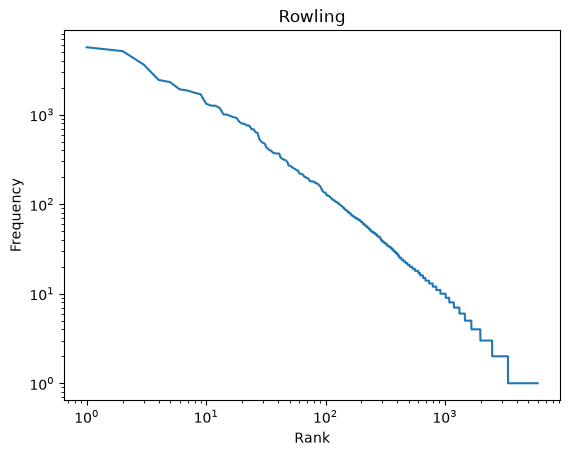

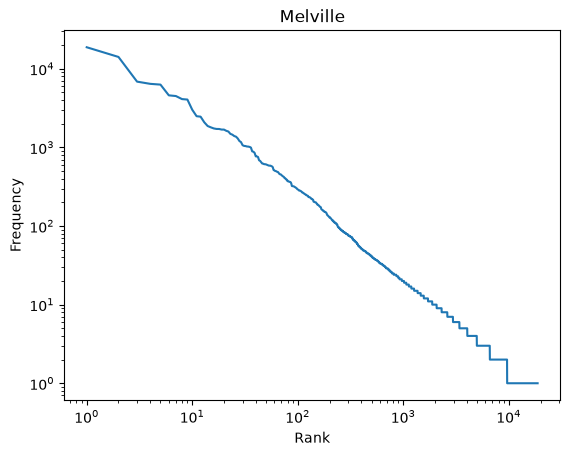

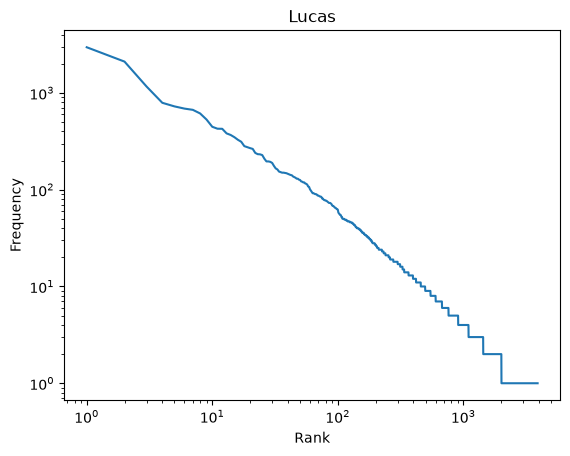

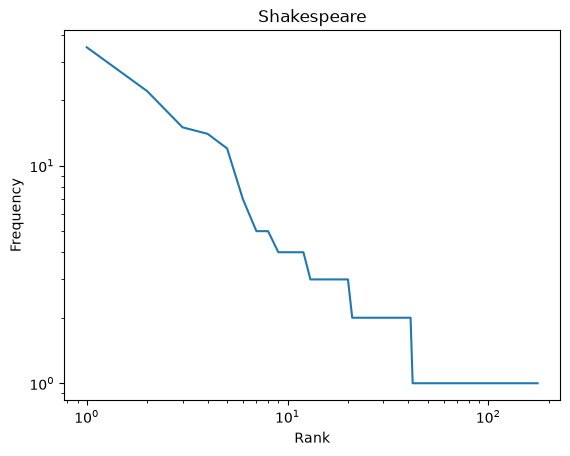

In [118]:
%matplotlib inline
import matplotlib.pyplot as plt

for author in books:
    frequency = frequencies_normalized[author]
    plt.loglog(range(1,len(frequency)+1), sorted(frequency.values(), reverse=True))
    plt.title(author)
    plt.ylabel("Frequency")
    plt.xlabel("Rank")
    plt.show()

## Probabilistic language models

### Random model
* Every word is independent from the other
* Every word has exactly the same probability

(not very reasonable but useful as a first approach)

In [119]:
def build_random_model(words):
    """
    Build a simple random (uniform) language model with normalization.
    All words are converted to lowercase so that the vocabulary is clean
    (e.g., 'The' and 'the' are treated as the same word).
    """

    # normalize: convert all tokens to lowercase
    words_normalized = [w.lower() for w in words]

    # create the vocabulary: a set of all unique normalized words
    vocabulary = set(words_normalized)

    # get the vocabulary size (number of unique words)
    voc_size = len(vocabulary)

    # initialize an empty dictionary that will map each word to its probability
    random_model = dict()

    # assign the same probability to each word
    # since probabilities must sum to 1, each word gets 1 / vocabulary_size
    for term in vocabulary:
        random_model[term] = 1 / voc_size  # uniform probability

    # return the dictionary {word: probability}
    return random_model


In [120]:
# create a dictionary to store one random model per author
random_models = dict()

# iterate through all authors in the books collection
for author in books:
    # build a random model for the current author
    # we pass the author's tokenized words (books_words[author]) to the function
    # the function normalizes them and assigns uniform probabilities
    random_models[author] = build_random_model(books_words[author])


Here we inspect one of the **random language models** we created.  
The object `random_models['Rowling']` is a dictionary where:  

- the **keys** are the words in the author's vocabulary (normalized to lowercase),  
- the **values** are their probabilities.  

Since this is a **random (uniform) model**, every word has exactly the same probability:  
`1 / vocabulary_size`.  


In [121]:
random_models['Rowling']

{'wickedly': 0.00016728002676480428,
 'disappeared': 0.00016728002676480428,
 'scrambling': 0.00016728002676480428,
 'laden': 0.00016728002676480428,
 'spawn': 0.00016728002676480428,
 'wakes': 0.00016728002676480428,
 'hooting': 0.00016728002676480428,
 'owners': 0.00016728002676480428,
 'watery': 0.00016728002676480428,
 'defeated': 0.00016728002676480428,
 'page': 0.00016728002676480428,
 'tame': 0.00016728002676480428,
 'slug': 0.00016728002676480428,
 'percy': 0.00016728002676480428,
 'stars': 0.00016728002676480428,
 'noises': 0.00016728002676480428,
 'horn': 0.00016728002676480428,
 'astonishment': 0.00016728002676480428,
 'get.': 0.00016728002676480428,
 'helicopters': 0.00016728002676480428,
 'extremely': 0.00016728002676480428,
 'kiss': 0.00016728002676480428,
 'africa': 0.00016728002676480428,
 'buttered': 0.00016728002676480428,
 'feelings': 0.00016728002676480428,
 'ours': 0.00016728002676480428,
 'wizened': 0.00016728002676480428,
 'tapdance': 0.00016728002676480428,
 'sa

#### Random model to classify new texts

In [122]:
books.keys()

dict_keys(['Rowling', 'Melville', 'Lucas', 'Shakespeare'])

What is the probability assigned to a piece of text by a model?

A **language model** assigns probabilities to sequences of words.  
The probability of a text is computed as the product of the probabilities of each word.  

- If the word is known (in the model’s vocabulary), we use its probability.  
- If the word is unknown, we assign it a very small probability (smoothing) instead of zero.  

This way, the model can still evaluate texts even if they contain words not seen in the training data.  


In [123]:
test_text = [
    "rebel troopers aim their weapons", # Lucas
    "to be, or not to be", # Shakespeare
    "posted like silent sentinels", # Melville
    "uncle vernon entered the kitchen", # Rowling
]

In [124]:
import math

In [125]:
def get_probability(text, model):
    """
    Compute the probability of a text given a language model.
    The model is a dictionary {word: probability}.
    """

    # Unknown words get a small non-zero probability so the product does not
    # collapse to 0. This is a FLOOR, not add-k smoothing: nothing is added to
    # the counts and no probability mass is taken from the words we did see,
    # so after this the model no longer sums to 1. Good enough for comparing
    # texts, but see the slides for real smoothing.
    unknown_probability = min(model.values()) / 1000


    # tokenize the input text into words
    words = [w.lower() for w in word_tokenize(text)]

    # initialize the overall probability of the text
    probability = 1

    # iterate through each word in the text
    for word in words:
        if word in model:
            # if the word is in the model, multiply by its probability
            probability *= model[word]  # multiplication rule for independent events
        else:
            # if the word is unknown, multiply by the small "unknown_probability"
            probability *= unknown_probability

    # return the final probability of the text
    return probability


def get_log_probability(text, model):
    """
    Compute the log-probability of a text given a language model.
    This avoids underflow and produces more interpretable values.
    """
    unknown_probability = min(model.values()) / 1000
    words = [w.lower() for w in word_tokenize(text)]
    log_prob = 0
    for word in words:
        if word in model:
            log_prob += math.log(model[word])
        else:
            log_prob += math.log(unknown_probability)
    return log_prob

#### How to interpret log-probabilities

When we work with log-probabilities:

- All values are **negative** (because `log(x)` is negative if `0 < x < 1`).
- The **closer the value is to 0**, the **higher the probability**.
- The **more negative the value**, the **lower the probability**.

Example:  

- `log-probability = -62.0` → higher probability  
- `log-probability = -92.5` → lower probability  

So, when comparing authors, **the author with the least negative log-probability is the most probable one**.


In [126]:
for test in test_text:
    print(f"Test text: \"{test}\"")
    for author in books:
        prob = get_probability(test, random_models[author])
        log_prob = get_log_probability(test, random_models[author])

        # show both the probability (scientific notation) and its log form
        print(f"  author: {author:<15}  probability: {prob:.2e}   log-probability: {log_prob:.2f}")

    print("-" * 50)

Test text: "rebel troopers aim their weapons"
  author: Rowling          probability: 1.31e-31   log-probability: -71.11
  author: Melville         probability: 4.30e-25   log-probability: -56.11
  author: Lucas            probability: 1.11e-18   log-probability: -41.34
  author: Shakespeare      probability: 5.92e-24   log-probability: -53.48
--------------------------------------------------
Test text: "to be, or not to be"
  author: Rowling          probability: 3.67e-27   log-probability: -60.87
  author: Melville         probability: 1.22e-30   log-probability: -68.88
  author: Lucas            probability: 7.29e-26   log-probability: -57.88
  author: Shakespeare      probability: 1.91e-16   log-probability: -36.19
--------------------------------------------------
Test text: "posted like silent sentinels"
  author: Rowling          probability: 7.83e-22   log-probability: -48.60
  author: Melville         probability: 8.07e-18   log-probability: -39.36
  author: Lucas            

#### Generating text with a random language model

So far, we have used language models to **evaluate** texts.  
Now, we will use them to **generate** new text.  

With a **random (uniform) model**, each word in the vocabulary has the same probability.  
This means that text generation is just random sampling from the set of words,  
so the result will look like a bag of words with no grammatical structure.  

This is useful as a *baseline* to understand how more advanced models (e.g., n-grams)  
can improve the quality of generated text.


Can we generate text from model?

In [127]:
import random

In [128]:
def generate_text_random(model, length=30):
    """
    Generate a sequence of words using a random (uniform) model.

    Parameters:
        model  - the random language model (dictionary {word: probability})
        length - number of words to generate (default = 30)
    """

    # random.choices picks k elements at random (with replacement) from a list
    # here we take k words from the model's vocabulary (model.keys())
    # since the model is uniform, all words have the same probability
    words = random.choices(list(model.keys()), k=length)

    # join the words into a single string, separated by spaces
    text = ' '.join(words)

    # return the generated text
    return text


In [129]:
for author in books:
    print(author)
    print(generate_text_random(random_models[author]),sep='\t')
    print()

Rowling
bludger finnigan cast president rows like fists dragged legendary carrying parrot amigo jerking sahara smoke swooped check pockets harder librarian shop leaked drop syllable talking every deserted icicles continue plant

Melville
self-esteem caressed canals smuggling embodiment describe mountainous weakling evolutions adorning stones overmuch wouldst tows earnest vicissitude saddest bring abandonment beseech claims tucked creaking cumbrous zealanders awhile short-warp smallness psalmody disorderliness

Lucas
targeting let barely crumbling controlled gaderffii fired readiness scoring courage count wink hangs delivered nowhere battering explain defensive blockhouse tables savage- wiping mock damned-fool nothing kids frigate mutter bright darklighter

Shakespeare
hue regard something pitch awry life dispised nobler die outrageous contumely the come with sweat off thousand remember himself ? take be ophelia them remember traveller in you sleep cast



### Unigram model

In the unigram model, the probability of each word depends on its **frequency of use** in the text.  
- Words that appear more often get a higher probability.  
- Rare words get a lower probability.  

This is a simple probabilistic model that captures some information about the distribution of words, unlike the random model where all words are equally probable.


In [130]:
from collections import Counter

def build_unigram_model(words):
    """
    Build a unigram language model from a list of words.
    Each word is normalized (lowercase) and assigned a probability
    proportional to its frequency.
    """

    # normalize all tokens to lowercase
    words_normalized = [w.lower() for w in words]

    # count how many times each word appears
    frequencies = Counter(words_normalized)

    # total number of word occurrences (including repetitions)
    occurrence_count = sum(frequencies.values())

    # initialize the dictionary that will store the model {word: probability}
    unigram_model = dict()

    # assign to each word its relative frequency as probability
    for term in frequencies:
        unigram_model[term] = frequencies[term] / occurrence_count  # P(word) = count(word) / total_words

    # return the unigram model
    return unigram_model


In [131]:
unigram_models = dict()
for author in books:
    unigram_models[author] = build_unigram_model(books_words[author])

In [132]:
unigram_models["Melville"]['already'], unigram_models["Lucas"]['already']

(0.0001327732715334106, 0.00015228426395939087)

Do probabilities sum up to one?

In [133]:
for author in books:
    print(author,sum(unigram_models[author].values()))

Rowling 1.0
Melville 1.0
Lucas 1.0
Shakespeare 1.0


What is the probability assigned to a piece of text by a model?

In [134]:
for test in test_text:
    print(f"Test text: \"{test}\"")  # print the test sentence
    for author in books:
        # compute probability and log-probability with the unigram model
        prob = get_probability(test, unigram_models[author])
        log_prob = get_log_probability(test, unigram_models[author])

        # print in aligned format:
        # - probability in scientific notation with 2 decimals
        # - log-probability with 2 decimals
        print(f"  author: {author:<15}  probability: {prob:.2e}   log-probability: {log_prob:.2f}")

    print("-" * 50)  # separator for readability


Test text: "rebel troopers aim their weapons"
  author: Rowling          probability: 2.30e-35   log-probability: -79.76
  author: Melville         probability: 1.33e-26   log-probability: -59.58
  author: Lucas            probability: 8.98e-17   log-probability: -36.95
  author: Shakespeare      probability: 2.48e-25   log-probability: -56.66
--------------------------------------------------
Test text: "to be, or not to be"
  author: Rowling          probability: 7.40e-16   log-probability: -34.84
  author: Melville         probability: 5.64e-15   log-probability: -32.81
  author: Lucas            probability: 1.94e-16   log-probability: -36.18
  author: Shakespeare      probability: 9.88e-13   log-probability: -27.64
--------------------------------------------------
Test text: "posted like silent sentinels"
  author: Rowling          probability: 1.83e-23   log-probability: -52.35
  author: Melville         probability: 1.17e-17   log-probability: -38.99
  author: Lucas            

#### Generating text with a unigram model
Can we generate text from model?

In [136]:
import random

def generate_text_unigram(model, length=30):
    words = random.choices(list(model.keys()), list(model.values()), k=length)
    text = ' '.join(words)
    return text

In [137]:
for author in books:
    print(author)
    print(generate_text_unigram(unigram_models[author]),sep='\t')
    print()

Rowling
it wood wants , back wood `` '' the took looking a '' the , buy and across garden . . 're just got left just had eye swarming long

Melville
, and wharves to i is from uses evidence o in what men with , a one seas judge . to and fluke-chains me beef old otherwise tawny , with

Lucas
colors suggest across you the cooked was fires to . . disappear leia stop , blows the by 15 . targeting biggs vader out is falcon . pleased on the

Shakespeare
bear calamity the sea come great and is mortal others thus the the office aye sleep the dread himself you currents , , of orisons , oppressor name quietus to



### Bigram model

In the **bigram model**, the probability of a word depends not only on how often it appears in the text,  
but also on the **context in which it appears** — specifically, the **preceding word**.  

This means that the model captures simple word-to-word dependencies.  
For example, the word *"wizard"* might be more probable after *"Harry"* than after *"the"*.  

Compared to the unigram model:  
- **Unigram**: words are independent: probability depends only on frequency.  
- **Bigram**: words depend on the previous word: probability depends on frequency **conditioned on context**.  


In [47]:
def build_bigram_model(words):
    """
    Build a bigram language model from a list of words.
    Words are normalized to lowercase before building the model.
    """
    # normalize words
    words_normalized = [w.lower() for w in words]

    # count unigram frequencies
    frequencies_contexts = Counter(words_normalized)

    # generate bigrams
    bigrams = nltk.bigrams(words_normalized)

    # count bigram frequencies
    frequencies_bigrams = Counter(bigrams)

    # initialize the bigram model
    bigram_model = dict()

    # compute conditional probabilities P(next | context)
    for bigram in frequencies_bigrams:
        context_word = bigram[0]
        word = bigram[1]
        if context_word not in bigram_model:
            bigram_model[context_word] = dict()
        bigram_model[context_word][word] = frequencies_bigrams[bigram] / frequencies_contexts[context_word]

    return bigram_model


Here we generate all **bigrams** (pairs of consecutive words) from the list `a`.  
So we see every adjacent pair of words in the sequence.

In [48]:
a = ['a', 'b','c', 'd', 'a','e', 'a', 'b']
list(nltk.bigrams(a))

[('a', 'b'),
 ('b', 'c'),
 ('c', 'd'),
 ('d', 'a'),
 ('a', 'e'),
 ('e', 'a'),
 ('a', 'b')]

Here we count how many times each **bigram** appears in the list.  

This shows that the bigram `('a','b')` occurs twice, while all the others occur only once.


In [49]:
Counter(nltk.bigrams(a))

Counter({('a', 'b'): 2,
         ('b', 'c'): 1,
         ('c', 'd'): 1,
         ('d', 'a'): 1,
         ('a', 'e'): 1,
         ('e', 'a'): 1})

Here we build the **bigram probabilistic model**.  

The model is a dictionary of dictionaries, where for each context word  we see the probability distribution of the next word.  


In [50]:
build_bigram_model(a)

{'a': {'b': 0.6666666666666666, 'e': 0.3333333333333333},
 'b': {'c': 0.5},
 'c': {'d': 1.0},
 'd': {'a': 1.0},
 'e': {'a': 1.0}}

Building bigram models for each author

We now build a **bigram model** for every author.  
Each model represents a dictionary of conditional probabilities:  

- Keys = context words (the preceding word).  
- Values = dictionaries mapping possible next words to their probabilities.  

So, for example:  
`bigram_models['Shakespeare']['the']['king']`  
would give the probability of seeing the word **"king"** after the word **"the"** in Shakespeare’s texts.


In [51]:
# create an empty dictionary to store one bigram model per author
bigram_models = dict()

# iterate through all authors
for author in books:
    # build the bigram model for the current author
    # input: list of tokenized words (books_words[author])
    # output: dictionary of conditional probabilities {context: {word: probability}}
    bigram_models[author] = build_bigram_model(books_words[author])


In [52]:
bigram_models['Lucas']

{'star': {'wars': 0.004310344827586207,
  ',': 0.021551724137931036,
  'plans': 0.004310344827586207,
  '!': 0.004310344827586207,
  '-': 0.25862068965517243,
  '.': 0.06465517241379311,
  'or': 0.004310344827586207,
  'alderaan': 0.004310344827586207,
  'battlestation': 0.004310344827586207,
  'system': 0.004310344827586207,
  'systems': 0.008620689655172414,
  'can': 0.004310344827586207,
  'as': 0.01293103448275862,
  'intercom': 0.03017241379310345,
  "'s": 0.03879310344827586,
  'docking': 0.004310344827586207,
  'ominously': 0.004310344827586207,
  'fleet': 0.004310344827586207,
  'begins': 0.004310344827586207,
  'tarkin': 0.004310344827586207,
  'moves': 0.004310344827586207,
  'approaching': 0.004310344827586207,
  'slowly': 0.004310344827586207,
  'now': 0.004310344827586207,
  'looming': 0.004310344827586207,
  'surface': 0.08189655172413793,
  'alarm': 0.004310344827586207,
  'laserbolts': 0.008620689655172414,
  'aims': 0.004310344827586207,
  'technical': 0.00431034482758

In [53]:
list(bigram_models['Lucas'].keys())[100:200]

['her',
 'starship',
 'custodian',
 'stolen',
 'that',
 'can',
 'save',
 'people',
 'and',
 'restore',
 'freedom',
 'awesome',
 'yellow',
 'tatooine',
 'emerges',
 'total',
 'eclipse',
 'two',
 'moons',
 'glowing',
 'darkness',
 'tiny',
 'silver',
 'spacecraft',
 'blockade',
 'runner',
 'firing',
 'lasers',
 'back',
 'ship',
 'pursed',
 'giant',
 'imperial',
 'stardestroyer',
 'hundreds',
 'deadly',
 'laserbolts',
 'streak',
 'causing',
 'solar',
 'fin',
 'craft',
 'disintegrate',
 'int',
 '-',
 'passageway',
 'explosion',
 'rocks',
 'robots',
 'artoo-detoo',
 '(',
 'r2-',
 'd2',
 ')',
 'see-threepio',
 'c-3po',
 'struggle',
 'make',
 'way',
 'shaking',
 'bouncing',
 'both',
 'are',
 'old',
 'battered',
 'artoo',
 'short',
 'claw-armed',
 'tripod',
 'his',
 'face',
 'mass',
 'computer',
 'lights',
 'surrounding',
 'radar',
 'eye',
 'threepio',
 'on',
 'other',
 'hand',
 'tall',
 'slender',
 'robot',
 'human',
 'proportions',
 'he',
 'has',
 'gleaming',
 'bronze-like',
 'metallic',
 'su

In [54]:
bigram_models['Lucas']['robot']

{'of': 0.029411764705882353,
 'could': 0.029411764705882353,
 'appears': 0.029411764705882353,
 'to': 0.08823529411764706,
 'scoots': 0.029411764705882353,
 'joins': 0.029411764705882353,
 'jumps': 0.058823529411764705,
 'repairs': 0.029411764705882353,
 '.': 0.2647058823529412,
 'a': 0.029411764705882353,
 'waddles': 0.029411764705882353,
 'onto': 0.029411764705882353,
 'is': 0.029411764705882353,
 ',': 0.058823529411764705,
 "'s": 0.029411764705882353,
 'by': 0.029411764705882353,
 'enters': 0.029411764705882353,
 'gives': 0.029411764705882353,
 'herding': 0.029411764705882353,
 'covered': 0.029411764705882353,
 'similar': 0.029411764705882353,
 'as': 0.029411764705882353}

Do probabilities sum up to one?

In [55]:
context_word = 'the'
for author in books:
    print(author, context_word, sum(bigram_models[author][context_word].values()))

Rowling the 1.0
Melville the 1.0
Lucas the 1.0
Shakespeare the 1.0


What is the probability assigned to a piece of text by a model?

In [56]:
def get_probability_bigram(text, model):
    """
    Compute the probability of a text given a bigram language model.
    Words are normalized to lowercase, and unseen bigrams receive a small probability.
    """

    # This computes P(w2|w1) * P(w3|w2) * ... only.
    # The chain rule also needs the first word, P(w1), which is missing.
    # The usual fix is to pad the text with a start token <s>, so the first
    # factor becomes P(w1|<s>) and the model has a distribution over openings.

    # Floor for unseen bigrams. this is a different value from the
    # min/1000 used by the unigram scorer, so log-probabilities from the two
    # models are NOT directly comparable to each other, only across authors
    # within the same model.
    unk_prob = 1e-6 

    # tokenize the text and normalize to lowercase
    words = [w.lower() for w in word_tokenize(text)]

    # generate all bigrams (pairs of consecutive words)
    bigrams = nltk.bigrams(words)

    # initialize probability
    probability = 1

    # iterate over each bigram in the text
    for context_word, word in bigrams:
        if context_word in model:                # if the context word exists in the model
            if word in model[context_word]:      # if the bigram (context, word) exists
                probability *= model[context_word][word]  # use its probability
            else:
                probability *= unk_prob          # unseen word in this context
        else:
            probability *= unk_prob              # unseen context word

    # return the final probability of the text
    return probability


In [57]:
for test in test_text:
    print(f"Test text: \"{test}\"")  # print the test sentence clearly

    for author in books:
        # compute probability with the bigram model
        prob = get_probability_bigram(test, bigram_models[author])

        # compute log-probability to make numbers more interpretable
        log_prob = math.log(prob) if prob > 0 else float('-inf')

        # print the results in a readable format
        # probability in scientific notation (e.g., 3.52e-45)
        # log-probability with 2 decimal places
        print(f"  author: {author:<15}  probability: {prob:.2e}   log-probability: {log_prob:.2f}")

    print("-" * 50)  # separator line between test cases


Test text: "rebel troopers aim their weapons"
  author: Rowling          probability: 1.00e-24   log-probability: -55.26
  author: Melville         probability: 4.99e-21   log-probability: -46.75
  author: Lucas            probability: 2.25e-05   log-probability: -10.70
  author: Shakespeare      probability: 1.00e-24   log-probability: -55.26
--------------------------------------------------
Test text: "to be, or not to be"
  author: Rowling          probability: 1.11e-09   log-probability: -20.62
  author: Melville         probability: 1.29e-09   log-probability: -20.47
  author: Lucas            probability: 1.45e-18   log-probability: -41.08
  author: Shakespeare      probability: 3.28e-04   log-probability: -8.02
--------------------------------------------------
Test text: "posted like silent sentinels"
  author: Rowling          probability: 1.00e-18   log-probability: -41.45
  author: Melville         probability: 2.24e-05   log-probability: -10.71
  author: Lucas            p

#### Generating text with a bigram model
Can we generate text from these models?

In [58]:
import random

def generate_text_bigram(model, context_word=None, length=30):
    """
    Generate text using a bigram model.

    Parameters:
        model        - the bigram model {context: {word: probability}}
        context_word - the initial word to start the generation (optional)
        length       - number of words to generate (default = 30)
    """

    # if no starting word is given, pick one at random from the model's contexts
    if context_word is None:
        context_word = random.choices(list(model.keys()), k=1)[0]

    # initialize the generated text
    text = ''

    # generate one word at a time
    for i in range(length):
        # get the probability distribution of words following the current context
        
        # a word that never starts a bigram has no continuation: stop here
        if context_word not in model:
            break
        context_model = model[context_word]


        # sample one word according to its probability given the context
        word = random.choices(
            list(context_model.keys()),        # possible next words
            list(context_model.values()),      # their probabilities
            k=1
        )[0]

        # append the word to the generated text
        text += word + ' '

        # update the context: the chosen word becomes the new context
        context_word = word

    # return the generated sequence of words as a string
    return text


In [59]:
for author in books:
    print(author)
    print(generate_text_bigram(bigram_models[author]),sep='\t')
    print()

Rowling
! '' a motorcycle , too . he was bending over to remember the twins insisted that 's car and into the stone 's professor mcgonagall turned slowly over his 

Melville
against tashtego ; - but without his sake , and ahab would yet in holiest on what present a succession of the case . under cover no means of the 

Lucas
into the control panel , firing at his flashy city attire is filled alcove for him ! luke 's wrong ? owen before we have to find more than his 

Shakespeare
; and enterprises of time , the unworthy takes , with a consummation devoutly to others that makes calamity of the dread of time , the thousand natural shocks that 



### N-gram model
Same as bigram model, but context is defined by n-1 preceeding words.

In [60]:
def build_ngram_model(words, n):
    # Convert all words to lowercase to ensure consistent counting
    words = [word.lower() for word in words]

    # Generate all (n-1)-grams to serve as contexts
    ngram_contexts = nltk.ngrams(words, n-1)
    # Count how often each (n-1)-gram occurs in the corpus
    contexts_frequencies = Counter(ngram_contexts)

    # Generate all n-grams (each consisting of a context + next word)
    ngrams = nltk.ngrams(words, n)
    # Count how often each n-gram occurs in the corpus
    ngram_frequencies = Counter(ngrams)

    # Initialize the n-gram model as a dictionary
    ngram_model = dict()

    # For each n-gram, compute the conditional probability of the last word
    # given its (n-1)-word context
    for ngram in ngram_frequencies:
        context = tuple(ngram[0:n-1])  # context is the sequence of n-1 previous words
        word = ngram[n-1]              # target word to predict

        # If this context has not been seen before, initialize its dictionary
        if context not in ngram_model:
            ngram_model[context] = dict()

        # Conditional probability: P(word | context) = count(context + word) / count(context)
        ngram_model[context][word] = ngram_frequencies[ngram] / contexts_frequencies[context]

    # Return the trained n-gram model as a nested dictionary:
    #   {context: {word: probability}}
    return ngram_model


In [61]:
a = ['a','b','c','d','e','a','b','h']
list(nltk.ngrams(a,4))

[('a', 'b', 'c', 'd'),
 ('b', 'c', 'd', 'e'),
 ('c', 'd', 'e', 'a'),
 ('d', 'e', 'a', 'b'),
 ('e', 'a', 'b', 'h')]

In [62]:
# Set the value of n for the n-gram model (here we use trigrams)
n = 3

# Initialize a dictionary to store one model per author
ngram_models = dict()

# Build an n-gram model for each author in the corpus
for author in books:
    # 'books_words[author]' contains the tokenized words for that author's texts
    ngram_models[author] = build_ngram_model(books_words[author], n)


In [63]:
list(ngram_models['Rowling'].keys())[:10]

[('harry', 'potter'),
 ('potter', 'and'),
 ('and', 'the'),
 ('the', 'sorcerer'),
 ('sorcerer', "'s"),
 ("'s", 'stone'),
 ('stone', 'chapter'),
 ('chapter', 'one'),
 ('one', 'the'),
 ('the', 'boy')]

In [64]:
books.keys()

dict_keys(['Rowling', 'Melville', 'Lucas', 'Shakespeare'])

In [65]:
ngram_models['Rowling'][('harry', 'potter')]

{'and': 0.03333333333333333,
 ',': 0.26666666666666666,
 'come': 0.03333333333333333,
 'day': 0.03333333333333333,
 'rolled': 0.03333333333333333,
 '--': 0.03333333333333333,
 'was': 0.03333333333333333,
 'in': 0.03333333333333333,
 'not': 0.03333333333333333,
 '...': 0.1,
 "'s": 0.1,
 '.': 0.06666666666666667,
 '!': 0.1,
 '?': 0.06666666666666667,
 'an': 0.03333333333333333}

Do probabilities sum up to one?

In [66]:
# Define a specific context (a tuple of words) to inspect in the models
contexts = [('harry', 'potter'), ('the', 'end')]

# For each author, check how the model behaves with this context
for author in books:
    for context in contexts:
      # Check whether the context exists in the author's model
      if context in ngram_models[author]:
          # Sum of conditional probabilities for all possible next words
          prob_sum = sum(ngram_models[author][context].values())
          print(author, context, prob_sum)
      else:
          # Handle the case where the context is not present in the model
          print(f"{author}: the bigram {context} does not exist in the model")

Rowling ('harry', 'potter') 1.0
Rowling ('the', 'end') 0.9696969696969697
Melville: the bigram ('harry', 'potter') does not exist in the model
Melville ('the', 'end') 1.0
Lucas: the bigram ('harry', 'potter') does not exist in the model
Lucas ('the', 'end') 0.9
Shakespeare: the bigram ('harry', 'potter') does not exist in the model
Shakespeare: the bigram ('the', 'end') does not exist in the model


What is the probabily of a piece of text to be generated by a model?

In [67]:
def get_probability_ngram(text, model, n):
    # As with the bigram scorer, the first n-1 words are never scored:
    # the product starts at the first complete n-gram. Padding the text with
    # n-1 start tokens <s> would fix it.

    # Floor for unseen bigrams. this is a different value from the
    # min/1000 used by the unigram scorer, so log-probabilities from the two
    # models are NOT directly comparable to each other, only across authors
    # within the same model.
    unk_prob = 1e-6

    # Tokenize the input text into individual words
    words = [w.lower() for w in word_tokenize(text)]

    # Generate all n-grams from the tokenized text
    ngrams = nltk.ngrams(words, n)

    # Initialize the overall probability for the text
    probability = 1

    # Iterate through all n-grams in the text
    for ngram in ngrams:
        # Separate the n-gram into its context (first n-1 words) and the target word
        context = tuple(ngram[0:n-1])
        word = ngram[n-1]

        # If the context exists in the model
        if context in model:
            # If the word is known given this context, use its conditional probability
            if word in model[context]:
                probability *= model[context][word]
            # Otherwise, use the unknown-word probability
            else:
                probability *= unk_prob
        # If the context is not in the model, use the unknown-context probability
        else:
            probability *= unk_prob

    # Return the total probability of the entire text under this n-gram model
    return probability


In [68]:
import math

# Loop over each test sentence
for test in test_text:
    print(f'Test text: "{test}"')  # print the test sentence clearly

    # Loop over each author (or book model)
    for author in books:
        # Compute probability with the n-gram model (here n=3 for trigrams)
        prob = get_probability_ngram(test, ngram_models[author], 3)

        # Compute log-probability for interpretability and numerical stability
        log_prob = math.log(prob) if prob > 0 else float('-inf')

        # Print results in the same readable format as before
        # probability in scientific notation, log-probability with 2 decimals
        print(f"  author: {author:<15}  probability: {prob:.2e}   log-probability: {log_prob:.2f}")

    # Separator line between test sentences
    print("-" * 50)


Test text: "rebel troopers aim their weapons"
  author: Rowling          probability: 1.00e-18   log-probability: -41.45
  author: Melville         probability: 1.00e-18   log-probability: -41.45
  author: Lucas            probability: 5.00e-01   log-probability: -0.69
  author: Shakespeare      probability: 1.00e-18   log-probability: -41.45
--------------------------------------------------
Test text: "to be, or not to be"
  author: Rowling          probability: 6.90e-26   log-probability: -57.94
  author: Melville         probability: 1.01e-12   log-probability: -27.62
  author: Lucas            probability: 1.67e-25   log-probability: -57.05
  author: Shakespeare      probability: 1.67e-01   log-probability: -1.79
--------------------------------------------------
Test text: "posted like silent sentinels"
  author: Rowling          probability: 1.00e-12   log-probability: -27.63
  author: Melville         probability: 1.00e+00   log-probability: 0.00
  author: Lucas            prob

#### Generating text with an n-gram model

Text generation using ngrams

`generate_text_ngram(model, context=None, length=30)`

Generates text from an *n-gram language model*.

- **context**: starting (n−1)-word tuple; if `None`, a random one is chosen.  
- At each step:
  1. Selects the next word based on the probability distribution `model[context]`.
  2. Adds the word to the output text.
  3. Updates the context by sliding the window forward.
- Repeats for `length` words and returns the generated text.


In [69]:
import random

def generate_text_ngram(model, context=None, length=30):
    # If no initial context is provided, pick one randomly from the model
    if context is None:
        context = random.choices(list(model.keys()), k=1)[0]

    # Initialize the generated text
    text = ''

    # Generate words one by one
    for i in range(length):
        # Retrieve the probability distribution for the current context
        
        # a word that never starts a n-gram has no continuation: stop here
        if context_word not in model:
            break
        context_model = model[context_word]


        # Sample the next word according to its probability
        word = random.choices(
            list(context_model.keys()),
            list(context_model.values()),
            k=1
        )[0]

        # Append the generated word to the text
        text += word + ' '

        # Update the context: slide the window by 1 word
        # (drop the first word and add the newly generated one)
        context = tuple(list(context[1:]) + [word])

    # Return the generated text as a string
    return text


In [70]:
# For each author, generate a sample of text using their n-gram model
for author in books:
    print(author)

    # Generate text from the author's model

    # This may raise a KeyError if the randomly chosen context does not exist
    # in the model (e.g., rare or missing bigram)
    print(generate_text_ngram(ngram_models[author]), sep='\t')
    print()


Rowling


Melville


Lucas


Shakespeare




In [71]:
# Safe version with error handling

# Generate text safely, even if a model has missing contexts
for author in books:
    print(author)

    try:
        # Try generating text normally
        print(generate_text_ngram(ngram_models[author]), sep='\t')
    except KeyError:
        # Handle missing context errors gracefully
        print(f"(Warning) Could not generate text for {author}: missing context in model.")

    print()

Rowling


Melville


Lucas


Shakespeare




In [72]:
list(ngram_models['Lucas'])[:20]

[('star', 'wars'),
 ('wars', 'episode'),
 ('episode', 'iv'),
 ('iv', 'a'),
 ('a', 'new'),
 ('new', 'hope'),
 ('hope', 'from'),
 ('from', 'the'),
 ('the', 'journal'),
 ('journal', 'of'),
 ('of', 'the'),
 ('the', 'whills'),
 ('whills', 'by'),
 ('by', 'george'),
 ('george', 'lucas'),
 ('lucas', 'revised'),
 ('revised', 'fourth'),
 ('fourth', 'draft'),
 ('draft', 'january'),
 ('january', '15')]

Longer ngrams capture more "semantic" but also tend to memorize text passages.

They need much more text to learn robust statistics.

In [73]:
n = 10
tengram_models = dict()
for author in books:
    tengram_models[author] = build_ngram_model(books_words[author], n)

In [74]:
list(tengram_models['Lucas'])[:10]

[('star', 'wars', 'episode', 'iv', 'a', 'new', 'hope', 'from', 'the'),
 ('wars', 'episode', 'iv', 'a', 'new', 'hope', 'from', 'the', 'journal'),
 ('episode', 'iv', 'a', 'new', 'hope', 'from', 'the', 'journal', 'of'),
 ('iv', 'a', 'new', 'hope', 'from', 'the', 'journal', 'of', 'the'),
 ('a', 'new', 'hope', 'from', 'the', 'journal', 'of', 'the', 'whills'),
 ('new', 'hope', 'from', 'the', 'journal', 'of', 'the', 'whills', 'by'),
 ('hope', 'from', 'the', 'journal', 'of', 'the', 'whills', 'by', 'george'),
 ('from', 'the', 'journal', 'of', 'the', 'whills', 'by', 'george', 'lucas'),
 ('the', 'journal', 'of', 'the', 'whills', 'by', 'george', 'lucas', 'revised'),
 ('journal',
  'of',
  'the',
  'whills',
  'by',
  'george',
  'lucas',
  'revised',
  'fourth')]

In [75]:
for author in books:
    print(author)
    print(generate_text_ngram(tengram_models[author]),sep='\t')
    print()

Rowling


Melville


Lucas


Shakespeare




#### Generating sentences

In [76]:
thatbook_words = books_words['Rowling']

In [77]:
thatbook_words[0:10]

['Harry',
 'Potter',
 'and',
 'the',
 'Sorcerer',
 "'s",
 'Stone',
 'CHAPTER',
 'ONE',
 'THE']

We create a **trigram language model** from the tokenized words of a book.


In [78]:
thatbook_3_model = build_ngram_model(thatbook_words,3)

We start generation with a context (a bigram) and produce 30 words.

In [79]:
context = ('harry','potter')
print(generate_text_ngram(thatbook_3_model,context,30))

We now create a **4-gram language model** from the tokenized words of a book.

In [80]:
thatbook_4_model = build_ngram_model(thatbook_words,4)

We start text generation using the **first context (3-word sequence)** found in the model’s keys.

In [81]:
context = list(thatbook_4_model.keys())[0]
print(context, '\n')
print(generate_text_ngram(thatbook_4_model,context,1000))

('harry', 'potter', 'and') 




### N-grams with nltk

In [82]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.lm.preprocessing import padded_everygram_pipeline, pad_both_ends

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /Users/francesco/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/francesco/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [83]:
n = 3

In [84]:
from nltk.util import ngrams as make_ngrams
from nltk.lm.preprocessing import pad_both_ends

sentences = [
    word_tokenize(sentence.lower())
    for sentence in sent_tokenize(books["Rowling"])
]

evaluation_ngrams = [
    gram
    for sentence in sentences
    for gram in make_ngrams(
        pad_both_ends(sentence, n=n),
        n,
    )
]

sentences_shak = [
    word_tokenize(sentence.lower())
    for sentence in sent_tokenize(books["Shakespeare"])
]

evaluation_ngrams_shak = [
    gram
    for sentence in sentences_shak
    for gram in make_ngrams(
        pad_both_ends(sentence, n=n),
        n,
    )
]

In [85]:
from nltk.lm import MLE

ngrams, tokens = padded_everygram_pipeline(n, sentences)  # padded means including <s> and </s>
model_mle = MLE(n)
model_mle.fit(ngrams, tokens)

In [86]:
from nltk.lm import Laplace

ngrams, tokens = padded_everygram_pipeline(n, sentences)  # padded means including <s> and </s>
model_lap = Laplace(n)
model_lap.fit(ngrams, tokens)

In [87]:
from nltk.lm import Lidstone

ngrams, tokens = padded_everygram_pipeline(n, sentences)
model_lidstone = Lidstone(gamma=0.01, order=n)
model_lidstone.fit(ngrams, tokens)

In [88]:
print("Vocabulary size:", len(model_lap.vocab))
print("MLE", "Rowling", model_mle.perplexity(evaluation_ngrams))  # why is this wrong?
print("MLE", "Shakespeare", model_mle.perplexity(evaluation_ngrams_shak))
print("Laplace", "Rowling", model_lap.perplexity(evaluation_ngrams))  # why is this wrong?
print("Laplace", "Shakespeare", model_lap.perplexity(evaluation_ngrams_shak))
print("Lidstone", "Rowling", model_lidstone.perplexity(evaluation_ngrams))  # why is this wrong?
print("Lidstone", "Shakespeare", model_lidstone.perplexity(evaluation_ngrams_shak))

Vocabulary size: 5980
MLE Rowling 4.007735315434249
MLE Shakespeare inf
Laplace Rowling 1036.673584060879
Laplace Shakespeare 4649.55004316846
Lidstone Rowling 34.927007607286264
Lidstone Shakespeare 4095.0744001992634


The comparison above is not completely fair... Why? Fix it

#### Generating sentences

In [89]:
generated_text = model_mle.generate(10)
print(" ".join(generated_text))

'' </s> </s> </s> </s> </s> </s> </s> </s> </s>


In [90]:
generated_text = model_mle.generate(50, text_seed=["<s>", "<s>"], random_seed=0)
print(" ".join(generated_text))

something was moving inside ; a lion , an ' wizard as i understand it , too busy with their backs while dudley hit them . </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s>


In [91]:
generated_text = model_mle.generate(50, text_seed=["Harry", "Potter", "took", "the"], random_seed=0)
print(" ".join(generated_text))

wand that chooses the wizard , why are n't you try her ? '' </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s>


In [92]:
generated_text = model_mle.generate(50, text_seed=["Barack", "Obama"], random_seed=0)
print(" ".join(generated_text))

than they were carried along a dark shop with a strangled cry , uncle vernon . </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s> </s>


In [93]:
model_mle.vocab.lookup("Barack"), model_mle.vocab.lookup("Obama")

('<UNK>', '<UNK>')

## Collocations

### Preprocessing

In [94]:
tokenized_text = books_words["Rowling"]
tokenized_text[:10]

['Harry',
 'Potter',
 'and',
 'the',
 'Sorcerer',
 "'s",
 'Stone',
 'CHAPTER',
 'ONE',
 'THE']

In [95]:
nltk_text = nltk.Text(tokenized_text)

In [96]:
nltk_text, type(nltk_text)

(<Text: Harry Potter and the Sorcerer 's Stone CHAPTER...>, nltk.text.Text)

The `.concordance()` method displays all occurrences of a given word  
along with a **window of surrounding context**.

This allows us to examine how the word is used across the text
- for instance, its typical collocations
- the variety of contexts in which it appears.

The output shows each occurrence on a separate line,  centered around the target word and truncated for readability.


In [97]:
nltk_text.concordance('Harry')

Displaying 25 of 1326 matches:
                                     Harry Potter and the Sorcerer 's Stone CHA
at 's what I heard yes , their son , Harry '' Mr. Dursley stopped dead . Fear f
e called Potter who had a son called Harry . Come to think of it , he was n't e
 n't even sure his nephew was called Harry . He 'd never even seen the boy . It
e again ? Howard , is n't it ? '' `` Harry . Nasty , common name , if you ask m
he tried to kill the Potter 's son , Harry . But -- he could n't . He could n't
e saying that when he could n't kill Harry Potter , Voldemort 's power somehow 
.. but how in the name of heaven did Harry survive ? '' `` We can only guess , 
l places ? '' `` I 've come to bring Harry to his aunt and uncle . They 're the
 the street , screaming for sweets . Harry Potter come and live here ! '' `` It
t be surprised if today was known as Harry Potter day in the future -- there wi
-- there will be books written about Harry -- every child in our world will kno
hough she

The `.similar()` method looks for **words that appear in similar contexts**  to a given target word within the text.

Rather than comparing meanings directly, it compares the **distributional context**, that is, the surrounding words.  

The output lists tokens that share comparable usage patterns, providing a simple way to explore semantic or stylistic similarity based on contextual co-occurrence.

In [98]:
nltk_text.similar('Harry')

he ron it they hermione hagrid his malfoy you snape him she and them
that dudley neville dumbledore the there


#### Visualizing word distribution with a dispersion plot

A **dispersion plot** shows where selected words appear throughout the text.  
Each occurrence of a target word is marked along the horizontal axis, which represents the position (token index) in the corpus.

This kind of visualization helps identify:
- recurring characters or themes,
- how evenly certain words are distributed,
- and whether terms tend to cluster in specific sections of the text.


In [99]:
import matplotlib.pyplot as plt
from nltk.draw.dispersion import dispersion_plot


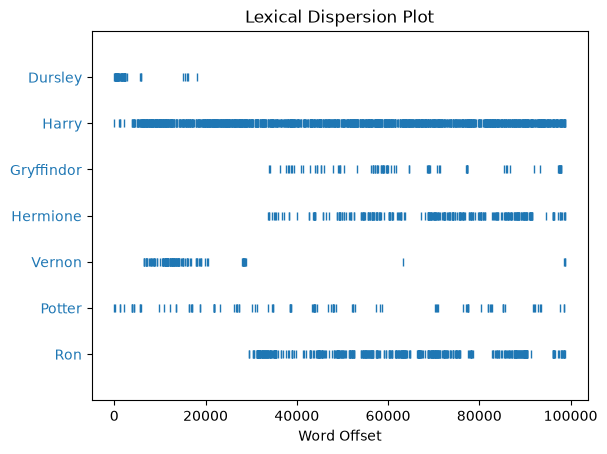

In [100]:
targets = ['Dursley', 'Harry', 'Gryffindor', 'Hermione', 'Vernon', 'Potter', 'Ron']
ax = dispersion_plot(tokenized_text, targets)
ax.set_yticks(list(range(len(targets))), reversed(targets), color="C0")

plt.show()


### Collocation Extraction

Collocations are pairs or groups of words that tend to appear together more often than would be expected by chance; for example, *"New York"*, *"machine learning"*, or *"strong tea"*.

They are essential for identifying **multi-word expressions**, **terminology**,  and **lexical patterns** that carry specific meaning beyond individual words.

Here, we will explore automatic extraction of collocations  using two different approaches:

1. **NLTK**: which provides classical statistical methods such as Pointwise Mutual Information (PMI), Chi-square, and t-score.  
2. **Gensim**: which uses a data-driven, iterative approach to detect phrases and multi-word units from large corpora.

### Collocations with NLTK

In [101]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/francesco/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Discovering collocations with `.collocations()`

The `.collocations()` method scans the text to identify **frequent word pairs** that occur together more often than would be expected by chance.  

Internally, it computes statistical association measures (by default, **PMI**) to detect **multi-word expressions** such as *“Harry Potter”* or *“Hogwarts School”*.

The output lists the most significant bigrams in the corpus, sorted by their association strength.

In [102]:
nltk_text.collocations()

Uncle Vernon; Professor McGonagall; Aunt Petunia; could n't; said Ron;
've got; said Harry; said Hagrid; Mr. Dursley; Privet Drive; common
room; would n't; Nimbus Two; Great Hall; n't know; Two Thousand; Mrs.
Dursley; Mr. Ollivander; invisibility cloak; Madam Pomfrey


Each collocation is shown as two words separated by a semicolon (`;`).

Examples such as:
- *“Uncle Vernon”*, *“Professor McGonagall”*, *“Aunt Petunia”*  
  meaningful named-entity–like expressions frequently used in the text.
- *“could n’t”*, *“would n’t”*, *“’ve got”*  
  common contractions or grammatical patterns, also captured as frequent word pairs.

So, the method retrieves **both lexical collocations** (multi-word names or fixed phrases)  
and **syntactic collocations** (frequent function–word combinations).  

This mixture is expected, since `.collocations()` focuses purely on **statistical frequency and association**, not on linguistic type.

--------------

#### Defining association measures for different n-gram lengths

NLTK provides a set of predefined *association measure classes* for evaluating how strongly words are linked together within n-grams.

Each class contains statistical scoring functions such as:
- **PMI** (Pointwise Mutual Information),
- **Chi-square (χ²)**,
- **t-test**, and others.

By creating measure objects for **bigrams**, **trigrams**, or **fourgrams**,  we can later choose the preferred association function when ranking collocations.

For example:
- `BigramAssocMeasures()`: for 2-word sequences  
- `TrigramAssocMeasures()`: for 3-word sequences  
- `QuadgramAssocMeasures()`: for 4-word sequences

In [103]:
from nltk.collocations import BigramAssocMeasures, TrigramAssocMeasures, QuadgramAssocMeasures, BigramCollocationFinder, TrigramCollocationFinder, QuadgramCollocationFinder

bigram_measures = nltk.collocations.BigramAssocMeasures()
trigram_measures = nltk.collocations.TrigramAssocMeasures()
fourgram_measures = nltk.collocations.QuadgramAssocMeasures()

#### Extracting collocations with `CollocationFinder`

The `Bigram/Trigram/QuadgramCollocationFinder` class gives more control over how collocations are identified and filtered.

This approach allows us to test different frequency thresholds and association measures (e.g., PMI, χ², t-score) on the same data.

In [104]:
# creates a finder object from the tokenized corpus.
b = BigramCollocationFinder.from_words(tokenized_text, window_size=2)

# removes all bigrams that occur fewer than 10 times,  keeping only statistically meaningful candidates.
b.apply_freq_filter(10)

# returns the top 10 bigrams ranked by Pointwise Mutual Information (PMI).
print(b.nbest(bigram_measures.pmi, 10))

print("---")

# returns the top 10 bigrams ranked by Chi-square.
print(b.nbest(bigram_measures.chi_sq, 10))

print("---")

# returns the top 10 bigrams ranked by t-score.
print(b.nbest(bigram_measures.student_t, 10))

[('Leaky', 'Cauldron'), ('Privet', 'Drive'), ('Nimbus', 'Two'), ('Two', 'Thousand'), ('Great', 'Hall'), ('Nicolas', 'Flamel'), ('Madam', 'Hooch'), ('Madam', 'Pomfrey'), ('Mrs.', 'Norris'), ('Aunt', 'Petunia')]
---
[('Privet', 'Drive'), ('Aunt', 'Petunia'), ('Leaky', 'Cauldron'), ('Uncle', 'Vernon'), ('Nimbus', 'Two'), ('Great', 'Hall'), ('Two', 'Thousand'), ('Professor', 'McGonagall'), ('Madam', 'Pomfrey'), ('Nicolas', 'Flamel')]
---
[('.', '``'), ("''", 'said'), ('?', "''"), (',', "''"), ('.', "''"), ("''", '``'), ('.', 'He'), ('!', "''"), (',', 'but'), (',', 'and')]



- **PMI** emphasizes *informativeness* (rare but strong associations).
- **χ² (Chi-square)** similarly promotes pairs whose **observed co-occurrence** deviates strongly from **expected under independence**, often producing a list very close to PMI on this corpus (same examples as above).
- **t-score** emphasizes *reliability* (frequent, consistent pairs), so punctuation+function-word patterns may surface at the top.

*Rule of thumb:*  
PMI/χ²: good for discovering **salient collocations**;  
t-score: good for **stable high-frequency** patterns.


In [105]:
from nltk.corpus import stopwords
import string

In [106]:
# Define a set of stopwords and punctuation
stop_words = set(stopwords.words('english'))
punct = set(string.punctuation)

additional_punctuation = ["''", '``']
for el in additional_punctuation:
    punct.add(el)

In [107]:
stop_words, punct

({'a',
  'about',
  'above',
  'after',
  'again',
  'against',
  'ain',
  'all',
  'am',
  'an',
  'and',
  'any',
  'are',
  'aren',
  "aren't",
  'as',
  'at',
  'be',
  'because',
  'been',
  'before',
  'being',
  'below',
  'between',
  'both',
  'but',
  'by',
  'can',
  'couldn',
  "couldn't",
  'd',
  'did',
  'didn',
  "didn't",
  'do',
  'does',
  'doesn',
  "doesn't",
  'doing',
  'don',
  "don't",
  'down',
  'during',
  'each',
  'few',
  'for',
  'from',
  'further',
  'had',
  'hadn',
  "hadn't",
  'has',
  'hasn',
  "hasn't",
  'have',
  'haven',
  "haven't",
  'having',
  'he',
  "he'd",
  "he'll",
  "he's",
  'her',
  'here',
  'hers',
  'herself',
  'him',
  'himself',
  'his',
  'how',
  'i',
  "i'd",
  "i'll",
  "i'm",
  "i've",
  'if',
  'in',
  'into',
  'is',
  'isn',
  "isn't",
  'it',
  "it'd",
  "it'll",
  "it's",
  'its',
  'itself',
  'just',
  'll',
  'm',
  'ma',
  'me',
  'mightn',
  "mightn't",
  'more',
  'most',
  'mustn',
  "mustn't",
  'my',
  'mys

**Filtering stopwords and punctuation in collocations**

You can clean your bigrams in two ways:

1. Using the apply_word_filter() method directly on the BigramCollocationFinder object.

2. Filtering the tokens manually before creating the finder.

In [108]:
# First approach
# Create a new BigramCollocationFinder and apply filters
b_clean = BigramCollocationFinder.from_words(tokenized_text)

# The apply_word_filter() method removes words that meet a given condition.
# In this case, it filters out tokens that are stopwords or punctuation marks
# before the bigrams are scored or extracted.
b_clean.apply_word_filter(lambda w: w.lower() in stop_words or w in punct)
b_clean.apply_freq_filter(10)

# Compare PMI and t-score after cleaning
print("Top bigrams by PMI:")
print(b_clean.nbest(bigram_measures.pmi, 10))

print("\nTop bigrams by t-score:")
print(b_clean.nbest(bigram_measures.student_t, 10))

Top bigrams by PMI:
[('Leaky', 'Cauldron'), ('Privet', 'Drive'), ('Nimbus', 'Two'), ('Two', 'Thousand'), ('Great', 'Hall'), ('Nicolas', 'Flamel'), ('Madam', 'Hooch'), ('Madam', 'Pomfrey'), ('Mrs.', 'Norris'), ('Aunt', 'Petunia')]

Top bigrams by t-score:
[('said', 'Harry'), ('Uncle', 'Vernon'), ('said', 'Ron'), ('could', "n't"), ('Professor', 'McGonagall'), ('Harry', "'s"), ('said', 'Hagrid'), ("'ve", 'got'), ('Aunt', 'Petunia'), ('ca', "n't")]


In [109]:
# Second approch
# Filter out stopwords and punctuation before creating the BigramCollocationFinder
token_clean = [w for w in tokenized_text if w.lower() not in stop_words and w not in punct]

# Create the bigram finder from the cleaned tokens
b_clean2 = BigramCollocationFinder.from_words(token_clean)

# Apply a frequency filter to keep only bigrams that appear at least 10 times
b_clean2.apply_freq_filter(10)

# Compare PMI and t-score after cleaning
print("Top bigrams by PMI:")
print(b_clean2.nbest(bigram_measures.pmi, 10))

print("\nTop bigrams by t-score:")
print(b_clean2.nbest(bigram_measures.student_t, 10))

Top bigrams by PMI:
[('Leaky', 'Cauldron'), ('Privet', 'Drive'), ('Nimbus', 'Two'), ('Two', 'Thousand'), ('Great', 'Hall'), ('Crabbe', 'Goyle'), ('Nicolas', 'Flamel'), ('Madam', 'Hooch'), ('Madam', 'Pomfrey'), ('Mrs.', 'Norris')]

Top bigrams by t-score:
[('Uncle', 'Vernon'), ('said', 'Harry'), ('said', 'Ron'), ('Professor', 'McGonagall'), ('could', "n't"), ('said', 'Hagrid'), ('Harry', "'s"), ("'ve", 'got'), ('Aunt', 'Petunia'), ('ca', "n't")]


In [110]:
t = TrigramCollocationFinder.from_words(tokenized_text)
t.apply_freq_filter(5)
t.nbest(trigram_measures.pmi, 10)

[('Every', 'Flavor', 'Beans'),
 ('Nimbus', 'Two', 'Thousand'),
 ('Devil', "'s", 'Snare'),
 ('King', "'s", 'Cross'),
 ('Mirror', 'of', 'Erised'),
 ('half', 'an', 'hour'),
 ('Ministry', 'of', 'Magic'),
 ('Gryffindor', 'common', 'room'),
 ('the', 'goal', 'posts'),
 ('aunt', 'and', 'uncle')]

In [111]:
q = QuadgramCollocationFinder.from_words(tokenized_text)
q.apply_freq_filter(5)
q.nbest(fourgram_measures.pmi, 10)

[('seven', 'hundred', 'and', 'thirteen'),
 ('Fred', 'and', 'George', 'Weasley'),
 ('the', 'Mirror', 'of', 'Erised'),
 ('to', 'get', 'past', 'Fluffy'),
 ('of', 'the', 'Fat', 'Lady'),
 ('in', 'the', 'Leaky', 'Cauldron'),
 ('the', 'Gryffindor', 'common', 'room'),
 ('What', 'are', 'you', 'doing'),
 ('portrait', 'of', 'the', 'Fat'),
 ('how', 'to', 'get', 'past')]

### Collocations with Gensim

Gensim provides an efficient and data-driven way to detect collocations, **based on statistical co-occurrence patterns** in a corpus.

Unlike NLTK’s explicit statistical measures (e.g., PMI, χ², t-score),  Gensim’s `Phrases` model learns multi-word expressions iteratively  and allows the inclusion of **connector words** (e.g., “of”, “the”)  to capture meaningful expressions like *“President of the United States”*.

In [112]:
# %pip install gensim

In [113]:
import gensim
from gensim.models.phrases import Phraser, Phrases

In [114]:
sentences[:5]

[['harry',
  'potter',
  'and',
  'the',
  'sorcerer',
  "'s",
  'stone',
  'chapter',
  'one',
  'the',
  'boy',
  'who',
  'lived',
  'mr.',
  'and',
  'mrs.',
  'dursley',
  ',',
  'of',
  'number',
  'four',
  ',',
  'privet',
  'drive',
  ',',
  'were',
  'proud',
  'to',
  'say',
  'that',
  'they',
  'were',
  'perfectly',
  'normal',
  ',',
  'thank',
  'you',
  'very',
  'much',
  '.'],
 ['they',
  'were',
  'the',
  'last',
  'people',
  'you',
  "'d",
  'expect',
  'to',
  'be',
  'involved',
  'in',
  'anything',
  'strange',
  'or',
  'mysterious',
  ',',
  'because',
  'they',
  'just',
  'did',
  "n't",
  'hold',
  'with',
  'such',
  'nonsense',
  '.'],
 ['mr.',
  'dursley',
  'was',
  'the',
  'director',
  'of',
  'a',
  'firm',
  'called',
  'grunnings',
  ',',
  'which',
  'made',
  'drills',
  '.'],
 ['he',
  'was',
  'a',
  'big',
  ',',
  'beefy',
  'man',
  'with',
  'hardly',
  'any',
  'neck',
  ',',
  'although',
  'he',
  'did',
  'have',
  'a',
  'very',
  

Gensim’s `Phrases` model expects a list of **tokenized sentences**,  where each sentence is represented as a list of tokens.

Since we already have the text split and tokenized into sentences,
we can directly use `tokenized_sentences` as input for Gensim’s Phrases model.

--------------------------------------------------------------

#### Default Gensim bigram model

Here we build a **default bigram model** using Gensim’s `Phrases`  with its standard parameter settings.

This quick setup lets us inspect the raw collocations automatically detected without any custom thresholds or connector-word adjustments.

The attribute `.phrasegrams` stores all detected bigrams  along with their internal association scores.


In [115]:
bigram_default = Phraser(Phrases(sentences))
bigram_default

In [116]:
bigram_default.phrasegrams

{"sorcerer_'s": 29.16169110286757,
 'mrs._dursley': 255.8125,
 'number_four': 240.76470588235293,
 'privet_drive': 1547.665625,
 'they_were': 18.501416405826497,
 'thank_you': 11.199751243781094,
 "did_n't": 34.83725128960943,
 'mr._dursley': 251.24441964285714,
 'so_much': 22.40197921273773,
 'the_dursleys': 10.926707115278544,
 'a_small': 12.502684389810426,
 'if_anyone': 18.84793301936159,
 'found_out': 24.55672432600904,
 'in_fact': 15.568118948824344,
 "n't_want": 10.287276406841624,
 'none_of': 13.014308426073132,
 'a_large': 17.258607471424586,
 'picked_up': 30.586277173913043,
 'tried_to': 16.942152435686918,
 'out_of': 13.565317452177036,
 'his_head': 19.899561247480136,
 'have_been': 24.156129839935616,
 'must_have': 40.15005162864921,
 'stared_at': 18.523748571428573,
 'looking_at': 12.496179591836736,
 "could_n't": 17.94574384974729,
 'edge_of': 13.014308426073132,
 'something_else': 17.95175438596491,
 'seemed_to': 17.519725814176244,
 'a_lot': 18.15992739739841,
 'his_fin

#### Training a bigram model with Gensim

The `Phrases` model learns which word pairs occur together frequently enough  to be treated as single multi-word units.

We include English stopwords as **connector words**,  
- so expressions like “Bank of America” or “President of the United States” are preserved.


In [117]:
# Train the bigram model
bigram_phrases = Phrases(
    sentences,
    min_count=5,        # ignore infrequent pairs
    threshold=10.0,     # higher threshold = fewer, more precise phrases
    connector_words=stop_words,  # allow stopwords as connectors
    delimiter="_"
)

In [118]:
# Build the efficient phraser
bigram = Phraser(bigram_phrases)

#### Applying the bigram model to the corpus

Once trained, the model can be used to merge frequent word pairs into single tokens connected by underscores.

In [119]:
# Apply the model to all tokenized sentences
sentences_bi = [bigram[sent] for sent in sentences]

# Show the first few transformed sentences
for i, s in enumerate(sentences_bi[:5]):
    print(i, " ".join(s))

0 harry potter and the sorcerer_'s stone chapter one the boy who lived mr. and mrs._dursley , of number_four , privet_drive , were proud to say that they were perfectly normal , thank you very much .
1 they were the last people you 'd expect to be involved in anything strange or mysterious , because they just did n't hold with such nonsense .
2 mr._dursley was the director of a firm called grunnings , which made drills .
3 he was a big , beefy man with hardly any neck , although he did have a very large mustache .
4 mrs._dursley was thin and blonde and had nearly twice the usual amount of neck , which came in very useful as she spent so much of her time craning over garden fences , spying on the neighbors .


#### Extracting and inspecting learned collocations

The `export_phrases()` method returns the collocations (multi-word expressions)  learned by the Gensim `Phrases` model.

Each element corresponds to a merged phrase such as *"harry_potter"* or *"uncle_vernon"*,  representing frequent word pairs identified across the corpus.

- Depending on the Gensim version, the output may be a list of strings  
(or byte strings in older versions).
- In either case,  the result shows the expressions that the model has learned to treat  as single multi-word units.

In [120]:
# Extract collocations (bigrams) learned by the model
phrases = bigram_phrases.export_phrases()

# Show the first merged expressions
for p in list(phrases)[:20]:
    print(p)

sorcerer_'s
mrs._dursley
number_four
privet_drive
mr._dursley
could_n't
something_else
minutes_later
never_seen
n't_know
'd_never
old_man
!_''
wo_n't
living_room
?_''
er_--
would_n't
``_oh
fell_asleep


#### Creating a DataFrame of collocations and their scores

To make it easier to inspect and analyze the collocations extracted by Gensim,  we can store them in a **pandas DataFrame**.

The attribute `.phrasegrams` contains all identified bigrams  
along with their internal association scores.  
We iterate through this dictionary, collect each pair and its score,  
and build a table with two columns:
- **collocation**: the word pair (as a tuple)  
- **score**: the association value assigned by the model

This structured format will allow us to sort, filter, or visualize the results more easily.


In [121]:
import pandas as pd

collocations = list()
for key, score in bigram.phrasegrams.items():
    collocations.append((key,score))

bigrams_df = pd.DataFrame(collocations,columns = ['collocation', 'score'])
bigrams_df.head()

,collocation,score
0,sorcerer_'s,27.280751
1,mrs._dursley,239.312500
2,number_four,225.235294
3,privet_drive,1447.840625
4,mr._dursley,235.039062


In [122]:
collocations[:10]

[("sorcerer_'s", 27.280751339574866),
 ('mrs._dursley', 239.3125),
 ('number_four', 225.23529411764704),
 ('privet_drive', 1447.840625),
 ('mr._dursley', 235.0390625),
 ("could_n't", 16.78823679469396),
 ('something_else', 16.79385964912281),
 ('minutes_later', 97.95116279069768),
 ('never_seen', 37.84276729559749),
 ("n't_know", 11.634783893514236)]

In [123]:
bigrams_df.sort_values(by=['score'],ascending=False)

,collocation,score
73,diagon_alley,1974.328125
3,privet_drive,1447.840625
53,smelting_stick,1203.400000
76,leaky_cauldron,1169.972222
92,lee_jordan,1148.700000
...,...,...
15,?_'',11.607130
37,looked_as_though,11.591854
31,could_see,11.583883
12,!_'',11.107331


In [124]:
# print all collocations  (descending order by score)
for (coll, score) in sorted(collocations,key=lambda x: x[1],reverse=True):
    print(f'"{coll}", score={score}')

"diagon_alley", score=1974.328125
"privet_drive", score=1447.840625
"smelting_stick", score=1203.3999999999999
"leaky_cauldron", score=1169.9722222222222
"lee_jordan", score=1148.7
"nine_and_three-quarters", score=877.4791666666666
"flavor_beans", score=779.9814814814814
"nicolas_flamel", score=752.125
"madam_pomfrey", score=719.982905982906
"madam_hooch", score=682.4837962962963
"fat_lady", score=601.6999999999999
"crabbe_and_goyle", score=584.9861111111111
"aunt_petunia", score=534.3031039136303
"bloody_baron", score=519.9876543209876
"mrs._norris", score=515.4423076923077
"invisibility_cloak", score=475.02631578947364
"fred_and_george", score=371.63823529411764
"fifty_points", score=368.17307692307696
"mrs._figg", score=358.96875
"platform_nine", score=350.9916666666667
"every_flavor", score=346.6584362139918
"chocolate_frogs", score=329.0546875
"mr._ollivander", score=321.7423611111111
"uncle_vernon", score=306.5472724703222
"common_room", score=305.21014492753625
"seamus_finnigan"

In [125]:
[a for a in list(bigrams_df['collocation']) if len(a.split("_")) > 2]

['aunt_and_uncle',
 'looked_as_though',
 'half_an_hour',
 'trying_to_find',
 'shook_his_head',
 'ministry_of_magic',
 'hundred_and_thirteen',
 'nine_and_three-quarters',
 'fred_and_george',
 'crabbe_and_goyle',
 'mirror_of_erised']

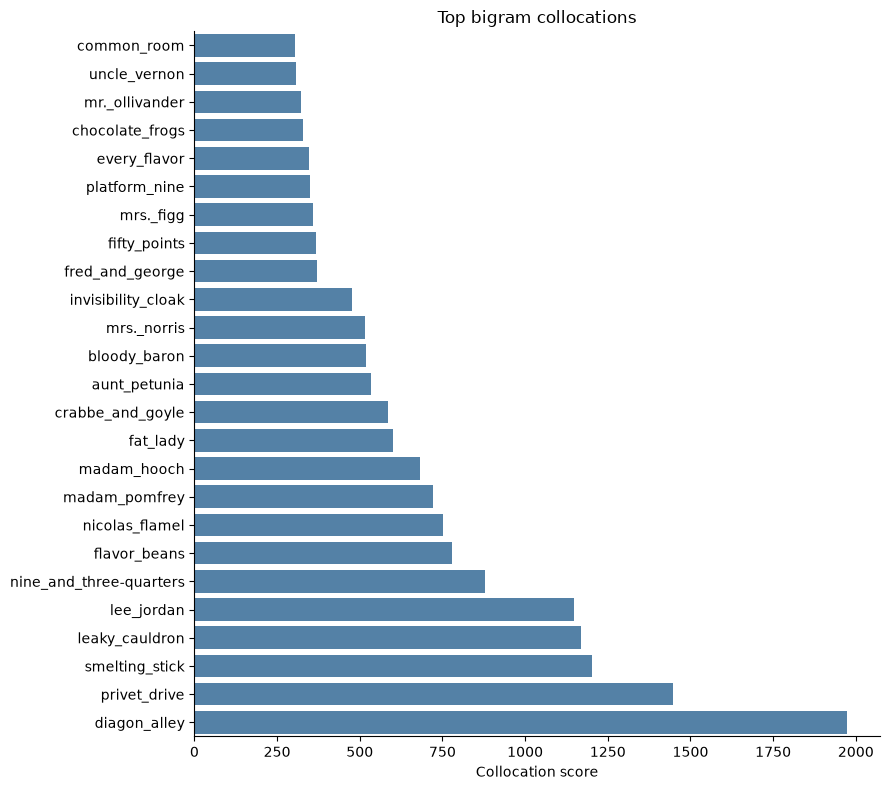

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

top = (
    bigrams_df
    .nlargest(25, "score")
    .sort_values("score")
)

plt.figure(figsize=(9, 8))

sns.barplot(
    data=top,
    x="score",
    y="collocation",
    color="steelblue",
)

plt.xlabel("Collocation score")
plt.ylabel("")
plt.title("Top bigram collocations")
sns.despine()
plt.tight_layout()
plt.show()

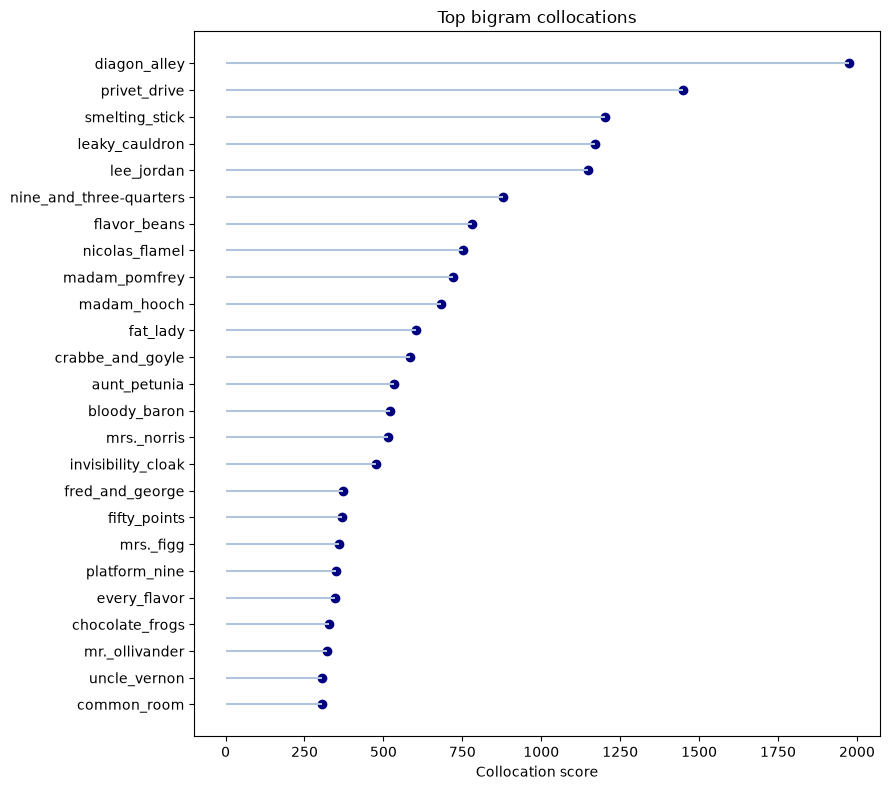

In [127]:
plt.figure(figsize=(9, 8))

plt.hlines(
    y=top["collocation"],
    xmin=0,
    xmax=top["score"],
    color="lightsteelblue",
)

plt.scatter(
    top["score"],
    top["collocation"],
    color="navy",
)

plt.xlabel("Collocation score")
plt.ylabel("")
plt.title("Top bigram collocations")
plt.tight_layout()
plt.show()

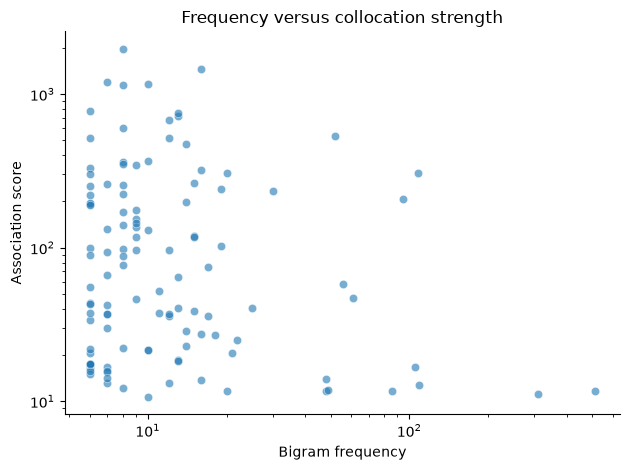

In [128]:
from collections import Counter
from itertools import chain
from nltk.util import bigrams

bigram_counts = Counter(
    chain.from_iterable(bigrams(sentence) for sentence in sentences)
)

bigrams_df["frequency"] = bigrams_df["collocation"].map(
    lambda phrase: bigram_counts[tuple(phrase.split("_", maxsplit=1))]
)

sns.scatterplot(
    data=bigrams_df,
    x="frequency",
    y="score",
    alpha=0.6,
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Bigram frequency")
plt.ylabel("Association score")
plt.title("Frequency versus collocation strength")
sns.despine()
plt.tight_layout()
plt.show()

**Interpreting the collocation plot**

Each point represents a bigram. Its horizontal position indicates its frequency in the corpus, while its vertical position indicates the strength of association between its words.

* **Top right:** frequent and strongly associated collocations, usually the most reliable.
* **Top left:** strong but relatively rare collocations, which may be distinctive but less reliable.
* **Bottom right:** frequent but weakly associated combinations, often involving common words.
* **Bottom left:** rare and weakly associated combinations, usually less informative.

This plot helps distinguish expressions that are frequent from expressions whose words occur together more often than expected. It is also useful for identifying meaningful phrases, names, fixed expressions, outliers, and possible tokenization errors.


In [129]:
import plotly.express as px

fig = px.scatter(
    bigrams_df,
    x="frequency",
    y="score",
    hover_name="collocation",
    log_x=True,
    log_y=True,
    opacity=0.6,
    title="Frequency versus collocation strength",
    labels={
        "frequency": "Bigram frequency,",
        "score": "Association score",
    },
)

fig.update_traces(
    marker={
        "size": 8,
        "color": "steelblue",
    }
)

fig.update_layout(
    template="plotly_white",
    hovermode="closest",
)

fig.show()

**Interactive collocation network**

Each node represents a word, while each edge represents a detected collocation. Node size indicates how many collocations contain that word, and edge thickness reflects the collocation score. Colors identify communities of words that frequently form collocations with one another.

The interactive graph allows us to zoom, select nodes, inspect connections, and identify hubs or thematic clusters. It is most useful when several collocations share words; isolated word pairs are usually easier to inspect in a table or ranked plot.

Open the `bigram_network.html` file to visualize it


In [130]:
import networkx as nx
from ipysigma import Sigma

filtered = (
    bigrams_df
    .query("frequency >= 10")
    .nlargest(100, "score")
)

G = nx.Graph()

for row in filtered.itertuples(index=False):
    word1, word2 = row.collocation.split("_", maxsplit=1)

    G.add_edge(
        word1,
        word2,
        score=row.score,
        frequency=row.frequency,
        collocation=row.collocation,
    )

Sigma.write_html(
    G,
    "bigrams_network.html",
    node_size=G.degree,
    node_size_range=(4, 18),
    edge_size="score",
    edge_size_range=(0.5, 5),
    node_metrics={"community": "louvain"},
    node_color="community",
    node_color_palette="Tableau10",
    default_edge_color="#cccccc",
    node_label=lambda node: node,
    edge_label="collocation",
    start_layout=True,
    fullscreen=True,
)

***Why do some trigrams appear even with a bigram model?***

Even though we trained only a **bigram** model,  
some three-word expressions (e.g. *"Fred_and_George"*, *"Ministry_of_Magic"*) may still appear.  
This behavior can arise from **two different causes**:

1. **Connector words**  
   When `connector_words=stop_words` is enabled, Gensim allows bigram formation  
   *across* function words such as “of”, “the”, “and”, etc.  
   This often leads to chained merges like  
  `"Ministry_of"` + `"of_Magic"` → `"Ministry_of_Magic"`.

2. **Greedy merging behavior of `Phraser`**  
   The `Phraser` applies the learned bigram rules **sequentially** and greedily:  
   - once a bigram is merged, it can immediately participate in another merge  
   within the same sentence.  
   For instance: `"Fred_and"` may merge again with `"George"` → `"Fred_and_George"`.

As a result, even a “bigram” model can yield a few **longer multi-word expressions**.  

If only strict two-word collocations are desired, you can either:
- remove `connector_words`, or  
- filter out tokens containing more than one underscore (`"_"`) (after applying the model).


-----------------------

#### Training a bigram model with Gensim with no connectors




In [131]:
# Train the bigram model
bigram_only_phrases = Phrases(
    sentences,
    min_count=5,  # ignore infrequent pairs
    threshold=10.0,  # higher threshold = fewer, more precise phrases
    delimiter="_"
    # by default connector_words=frozenset()
)

# Build the efficient phraser
bigram_only = Phraser(bigram_only_phrases)

# Apply the model to all tokenized sentences
sentences_only_bi = [bigram_only[sent] for sent in sentences]

collocations_bigrams = list()
for key, score in bigram_only.phrasegrams.items():
    collocations_bigrams.append((key,score))

bigrams_only_df = pd.DataFrame(collocations_bigrams,columns = ['collocation', 'score'])


In [132]:
[a for a in list(bigrams_only_df['collocation']) if len(a.split("_")) > 2]

[]

In [133]:
bigrams_only_df

,collocation,score
0,sorcerer_'s,29.161691
1,mrs._dursley,255.812500
2,number_four,240.764706
3,privet_drive,1547.665625
4,they_were,18.501416
...,...,...
294,miss_granger,277.064615
295,quidditch_match,125.063889
296,get_past,43.177176
297,invisibility_cloak,507.778195


#### Training a bigram model with Gensim without stopwords

To observe how stopwords affect collocation detection,  
we can rebuild the bigram model after removing all stopwords from the text.

Since stopwords (e.g., *the*, *of*, *and*) act as common connectors,  excluding them prevents the model from creating phrases that span across  
- such function words, resulting in fewer, more focused collocations.


In [134]:
#elements_to_remove = stop_words.union(punct)
elements_to_remove = punct

In [135]:
# Remove stopwords from each tokenized sentence
tokenized_no_stop = [
    [word for word in sent if word.lower() not in elements_to_remove]
    for sent in sentences
]

# Train a new bigram model without stopwords
bigram_nostop_phrases = Phrases(
    tokenized_no_stop,
    min_count=5,
    threshold=10.0,
    # connector_words=list(stop_words),
    delimiter="_"
)

# Build the efficient phraser
bigram_nostop = Phraser(bigram_nostop_phrases)

# Apply the model to all tokenized sentences
sentences_nostop = [bigram_nostop[sent] for sent in sentences]

collocations_nostop = list()
for key, score in bigram_nostop.phrasegrams.items():
    collocations_nostop.append((key,score))

bigrams_nostop_df = pd.DataFrame(collocations_nostop,columns = ['collocation', 'score'])


In [136]:
[a for a in list(bigrams_nostop_df['collocation']) if len(a.split("_")) > 2]

[]

In [137]:
bigrams_nostop_df

,collocation,score
0,sorcerer_'s,28.055408
1,mrs._dursley,246.107955
2,number_four,231.631016
3,privet_drive,1488.953125
4,they_were,17.799544
...,...,...
264,miss_granger,266.553846
265,quidditch_match,120.319444
266,get_past,41.539199
267,invisibility_cloak,488.515038


#### Building bigrams and trigrams iteratively

Gensim allows collocation extraction to be applied **iteratively**:
1. First, a bigram model learns frequent two-word expressions.
2. Then, the corpus transformed with bigrams is used to learn trigrams.

Including stopwords as `connector_words` enables the detection of longer,
natural phrases such as *"President_of_the_United_States"*.

This step shows how to build both models sequentially using `Phrases` and `Phraser`.


In [138]:
# Train a bigram model, keeping stopwords as connector words
bigram = Phraser(Phrases(sentences, connector_words=list(stop_words)))

# Apply the bigram model to all tokenized sentences
# Frequent pairs like ("Harry", "Potter") become single tokens: "Harry_Potter"
sentences_with_bigrams = bigram[sentences]

# Train a trigram model on the bigram-transformed sentences
# This allows detecting longer multi-word expressions (e.g. "President_of_the_United_States")
trigram = Phraser(Phrases(sentences_with_bigrams, connector_words=list(stop_words)))


**Note: building higher-order collocations from bigrams**

Once the bigram model has been trained and applied,  the resulting transformed corpus can be used as input to a new `Phrases` model  to discover **longer expressions**, such as trigrams or fourgrams.

This is an **iterative process**:
- The **bigram** model finds frequent word pairs.  
- The **trigram** model then learns from the bigram-expanded text,  
  combining adjacent bigrams into longer, meaningful units.

In other words, higher-order collocations can only be obtained  *from the already merged lower-order ones*,  not directly from the original tokenized text.


In [139]:
collocations_tri = list()

# Loop through each trigram (key) and its associated score
for key, score in trigram.phrasegrams.items():
    # Append the trigram and its score as a tuple to the list
    collocations_tri.append((key, score))

# Convert the list of tuples into a pandas DataFrame with two columns
trigrams_df = pd.DataFrame(collocations_tri, columns=['collocation', 'score'])

# Sort the DataFrame by score in descending order and reset the index
trigrams_df.sort_values(by='score', ascending=False, inplace=True, ignore_index=True)

trigrams_df

,collocation,score
0,uncle_vernon,109836.625000
1,aunt_petunia,100239.250000
2,mrs._norris,59717.000000
3,lee_jordan,21327.500000
4,professor_mcgonagall,21327.500000
...,...,...
118,said_dumbledore,12.239279
119,''_said,11.744230
120,must_'ve,11.471023
121,even_though,10.551639


In [140]:
[a for a in list(trigrams_df['collocation']) if len(a.split("_")) > 3]

['vault_seven_hundred_and_thirteen', 'platform_nine_and_three-quarters']